going to get looking at some data

In [13]:
import pandas as pd
import numpy as np

big_data_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\2015-2025jSPXoptions.csv"

big_data = pd.read_csv(big_data_filepath)



In [14]:
# Inspect data structure
print("Dataset shape:", big_data.shape)
print("\nColumn names and types:")
print(big_data.info())
print("\nFirst few rows:")
print(big_data.head(5))
print("\nBasic statistics:")
print(big_data.describe())
print("\nData types:")
print(big_data.dtypes)
print("\nMissing values:")
print(big_data.isnull().sum())

Dataset shape: (42225530, 23)

Column names and types:
<class 'pandas.DataFrame'>
RangeIndex: 42225530 entries, 0 to 42225529
Data columns (total 23 columns):
 #   Column            Dtype  
---  ------            -----  
 0   secid             int64  
 1   date              str    
 2   symbol            str    
 3   exdate            str    
 4   cp_flag           str    
 5   strike_price      int64  
 6   best_bid          float64
 7   best_offer        float64
 8   volume            int64  
 9   open_interest     int64  
 10  impl_volatility   float64
 11  delta             float64
 12  gamma             float64
 13  vega              float64
 14  theta             float64
 15  optionid          int64  
 16  forward_price     float64
 17  expiry_indicator  str    
 18  index_flag        int64  
 19  issue_type        str    
 20  industry_group    float64
 21  issuer            str    
 22  exercise_style    str    
dtypes: float64(9), int64(6), str(8)
memory usage: 7.2 GB
None

Fi

In [15]:
columns_to_keep = ["secid", "date", "exdate", "cp_flag", "strike_price", "best_bid", "best_offer",
                    "optionid", "exercise_style", "delta", "vega", "gamma", "impl_volatility"]

filtered_data = big_data[columns_to_keep]
# Rename strike_price to K and divide by 1000
filtered_data = filtered_data.rename(columns={'strike_price': 'K'})
filtered_data['K'] = filtered_data['K'] / 1000

print(filtered_data.head(5))

#about equal number of calls and puts
#only european options

    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  02/01/2015  17/01/2015       C   100.0    1956.4      1959.6   
1  108105  02/01/2015  17/01/2015       C  1000.0    1056.7      1059.9   
2  108105  02/01/2015  17/01/2015       C  1025.0    1031.7      1034.9   
3  108105  02/01/2015  17/01/2015       C  1050.0    1006.7      1009.8   
4  108105  02/01/2015  17/01/2015       C  1075.0     981.7       984.8   

    optionid exercise_style     delta      vega     gamma  impl_volatility  
0  101234071              E       NaN       NaN       NaN              NaN  
1  101234072              E  0.999103  1.179546  0.000006         1.222229  
2  101234073              E  0.999083  1.204660  0.000006         1.181493  
3  101234074              E  0.999391  0.808892  0.000005         1.092237  
4  101234075              E  0.999382  0.820990  0.000005         1.054338  


In [16]:
# Convert date column to datetime format (dd/mm/yyyy)
filtered_data['date'] = pd.to_datetime(filtered_data['date'], format='%d/%m/%Y')
filtered_data['exdate'] = pd.to_datetime(filtered_data['exdate'], format='%d/%m/%Y')

# Filter data to only include dates between 02/16/2015 and 01/07/2021
cutoff_date_start = pd.to_datetime('2015-10-16')
cutoff_date_end = pd.to_datetime('2021-07-01')
filtered_data = filtered_data[(filtered_data['date'] >= cutoff_date_start) & (filtered_data['date'] < cutoff_date_end)]

print(f"Dataset shape after date filter: {filtered_data.shape}")
print(f"\nDate range: {filtered_data['date'].min()} to {filtered_data['date'].max()}")
print(f"\nFirst few rows:")
print(filtered_data.head())

Dataset shape after date filter: (18194288, 13)

Date range: 2015-10-16 00:00:00 to 2021-06-30 00:00:00

First few rows:
          secid       date     exdate cp_flag       K  best_bid  best_offer  \
1561744  108105 2015-10-16 2015-11-20       C  1000.0    1025.3      1030.0   
1561745  108105 2015-10-16 2015-11-20       C  1025.0    1000.4      1005.0   
1561746  108105 2015-10-16 2015-11-20       C  1050.0     975.4       980.0   
1561747  108105 2015-10-16 2015-11-20       C  1075.0     950.4       955.1   
1561748  108105 2015-10-16 2015-11-20       C  1100.0     925.4       930.1   

          optionid exercise_style     delta      vega     gamma  \
1561744  108485570              E  0.996078  2.218131  0.000007   
1561745  108485571              E  0.995777  2.784215  0.000009   
1561746  108485572              E  0.995758  2.818352  0.000010   
1561747  108485573              E  0.995439  3.404782  0.000012   
1561748  108485574              E  0.995409  3.459122  0.000013   

 

In [17]:
# Load SPX price data
spx_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\S&P 500 Historical Data 2015-2022.csv"  # Update filename if needed

spx_data = pd.read_csv(spx_filepath)

# Convert SPX date column to datetime format (mm/dd/yyyy)
spx_data['Date'] = pd.to_datetime(spx_data['Date'], format='%m/%d/%Y')

# Convert both date columns to date only (removing time component) for proper merging
# First ensure filtered_data['date'] is datetime before converting
if not pd.api.types.is_datetime64_any_dtype(filtered_data['date']):
    filtered_data['date'] = pd.to_datetime(filtered_data['date'])
    
filtered_data['date'] = filtered_data['date'].dt.date
filtered_data['exdate'] = filtered_data['exdate'].dt.date
spx_data['Date'] = spx_data['Date'].dt.date

print(spx_data.head())

# Merge filtered_data with spx_data on date columns
filtered_data = filtered_data.merge(spx_data[['Date', 'Price']], 
                                    left_on='date', 
                                    right_on='Date', 
                                    how='left')

# Rename 'Price' to 'S' and drop the duplicate 'Date' column
filtered_data = filtered_data.rename(columns={'Price': 'S'})
filtered_data = filtered_data.drop(columns=['Date'])



# Remove duplicate S columns, keeping only the first one
s_columns = [col for col in filtered_data.columns if col == 'S']
if len(s_columns) > 1:
    # Get all columns and remove duplicates
    filtered_data = filtered_data.loc[:, ~filtered_data.columns.duplicated(keep='first')]
    print("Removed duplicate columns")

print("Merge complete!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"\nFirst few rows:")
print(filtered_data.head())

         Date    Price      Open      High       Low  Vol. Change %
0  2025-10-03  6715.79  6,722.14  6,750.87  6,705.67   NaN    0.01%
1  2025-10-02  6715.35  6,731.31  6,731.94  6,693.23   NaN    0.06%
2  2025-10-01  6711.20  6,664.92  6,718.48  6,656.20   NaN    0.34%
3  2025-09-30  6688.46  6,656.19  6,691.25  6,641.00   NaN    0.41%
4  2025-09-29  6661.21  6,661.58  6,677.31  6,644.49   NaN    0.26%
Merge complete!
Filtered data shape: (18194288, 14)

First few rows:
    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  2015-10-16  2015-11-20       C  1000.0    1025.3      1030.0   
1  108105  2015-10-16  2015-11-20       C  1025.0    1000.4      1005.0   
2  108105  2015-10-16  2015-11-20       C  1050.0     975.4       980.0   
3  108105  2015-10-16  2015-11-20       C  1075.0     950.4       955.1   
4  108105  2015-10-16  2015-11-20       C  1100.0     925.4       930.1   

    optionid exercise_style     delta      vega     gamma  impl_volatili

In [18]:
vix_filepath = r"C:\Users\samib\OneDrive - Imperial College London\Imperial\Education\Year 4\Masters Project\Code\MastersProject\Data\Full_VIX_History.csv"  # Update filename if needed

vix_data = pd.read_csv(vix_filepath)

# Convert VIX date column to datetime format (mm/dd/yyyy)
vix_data['DATE'] = pd.to_datetime(vix_data['DATE'], format='%m/%d/%Y')

# Convert DATE to date only (removing time component) to match filtered_data['date']
vix_data['DATE'] = vix_data['DATE'].dt.date


print(vix_data.head())

# Merge filtered_data with vix_data on date columns
filtered_data = filtered_data.merge(vix_data[['DATE', 'CLOSE']], 
                                    left_on='date', 
                                    right_on='DATE', 
                                    how='left')

# Rename 'CLOSE' to 'sigma' and drop the duplicate 'DATE' column
filtered_data = filtered_data.rename(columns={'CLOSE': 'sigma'})
filtered_data = filtered_data.drop(columns=['DATE'])

#turn sigma into percentage
filtered_data['sigma'] = filtered_data['sigma'] / 100

print("Merge complete!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"\nFirst few rows:")
print(filtered_data.head())

         DATE   OPEN   HIGH    LOW  CLOSE
0  1990-01-02  17.24  17.24  17.24  17.24
1  1990-01-03  18.19  18.19  18.19  18.19
2  1990-01-04  19.22  19.22  19.22  19.22
3  1990-01-05  20.11  20.11  20.11  20.11
4  1990-01-08  20.26  20.26  20.26  20.26
Merge complete!
Filtered data shape: (18194288, 15)

First few rows:
    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  2015-10-16  2015-11-20       C  1000.0    1025.3      1030.0   
1  108105  2015-10-16  2015-11-20       C  1025.0    1000.4      1005.0   
2  108105  2015-10-16  2015-11-20       C  1050.0     975.4       980.0   
3  108105  2015-10-16  2015-11-20       C  1075.0     950.4       955.1   
4  108105  2015-10-16  2015-11-20       C  1100.0     925.4       930.1   

    optionid exercise_style     delta      vega     gamma  impl_volatility  \
0  108485570              E  0.996078  2.218131  0.000007         0.785110   
1  108485571              E  0.995777  2.784215  0.000009         0.7771

In [19]:
#want to add interest rates now!!!
interestrate_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\yield-curve-rates-2015-2025.csv"  # Update filename if needed

ir_data = pd.read_csv(interestrate_filepath)

def parse_mixed_date(date_str):
    try:
        # Try mm/dd/yyyy format first
        return pd.to_datetime(date_str, format='%m/%d/%Y')
    except:
        try:
            # Fall back to mm/dd/yy format
            return pd.to_datetime(date_str, format='%m/%d/%y')
        except:
            print(f"Unrecognized date format: {date_str}")

ir_data['Date'] = ir_data['Date'].apply(parse_mixed_date).dt.date

# Rename columns
ir_data = ir_data.rename(columns={
    '1 Mo': 'r 1 Mo',
    '3 Mo': 'r 3 Mo',
    '6 Mo': 'r 6 Mo'
})

# Merge interest rate data with filtered_data
filtered_data = filtered_data.merge(ir_data[['Date', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo']], 
                                    left_on='date', 
                                    right_on='Date', 
                                    how='left')

# Drop the duplicate Date column
filtered_data = filtered_data.drop(columns=['Date'])

rate_cols = ['r 1 Mo', 'r 3 Mo', 'r 6 Mo']

# strip weird characters and coerce to numbers
for c in rate_cols:
    filtered_data[c] = (
        filtered_data[c]
        .astype(str)
        .str.replace('%','', regex=False)
        .str.replace(',','', regex=False)
        .str.strip()
    )
    filtered_data[c] = pd.to_numeric(filtered_data[c], errors='coerce')

# now divide by 100 (if the values are in percent units like 5.25)
filtered_data[rate_cols] = filtered_data[rate_cols] / 100


print("Interest rate merge complete!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"Columns: {list(filtered_data.columns)}")
print(f"\nFirst few rows:")
print(filtered_data.head())



Interest rate merge complete!
Filtered data shape: (18194288, 18)
Columns: ['secid', 'date', 'exdate', 'cp_flag', 'K', 'best_bid', 'best_offer', 'optionid', 'exercise_style', 'delta', 'vega', 'gamma', 'impl_volatility', 'S', 'sigma', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo']

First few rows:
    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  2015-10-16  2015-11-20       C  1000.0    1025.3      1030.0   
1  108105  2015-10-16  2015-11-20       C  1025.0    1000.4      1005.0   
2  108105  2015-10-16  2015-11-20       C  1050.0     975.4       980.0   
3  108105  2015-10-16  2015-11-20       C  1075.0     950.4       955.1   
4  108105  2015-10-16  2015-11-20       C  1100.0     925.4       930.1   

    optionid exercise_style     delta      vega     gamma  impl_volatility  \
0  108485570              E  0.996078  2.218131  0.000007         0.785110   
1  108485571              E  0.995777  2.784215  0.000009         0.777109   
2  108485572              E  0.995

In [20]:
# Convert S and K to numeric types
filtered_data['S'] = pd.to_numeric(filtered_data['S'], errors='coerce')
filtered_data['K'] = pd.to_numeric(filtered_data['K'], errors='coerce')

# Convert date columns back to datetime for arithmetic operations
filtered_data['date'] = pd.to_datetime(filtered_data['date'])
filtered_data['exdate'] = pd.to_datetime(filtered_data['exdate'])

# Calculate new columns
# mid: midpoint of bid-ask spread
filtered_data['mid'] = (filtered_data['best_bid'] + filtered_data['best_offer']) / 2

# T: time to expiration in years
filtered_data['T'] = (filtered_data['exdate'] - filtered_data['date']).dt.days / 365.0

# Log-moneyness: log(S/K)
filtered_data['log_moneyness'] = np.log(filtered_data['S'] / filtered_data['K'])

# Remove duplicate S columns, keeping only the first one
s_columns = [col for col in filtered_data.columns if col == 'S']
if len(s_columns) > 1:
    # Get all columns and remove duplicates
    filtered_data = filtered_data.loc[:, ~filtered_data.columns.duplicated(keep='first')]
    print("Removed duplicate columns")

# Debug: Check cp_flag values before mapping
print("cp_flag values before mapping:")
print(filtered_data['cp_flag'].unique())
print(f"cp_flag data type: {filtered_data['cp_flag'].dtype}")
print(f"cp_flag null count: {filtered_data['cp_flag'].isnull().sum()}")

filtered_data["cp_flag"] = filtered_data["cp_flag"].map({"C": 1, "P": 0})

print("\nNew columns created!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"\nColumns: {list(filtered_data.columns)}")
print(f"\nFirst few rows:")
print(filtered_data.head())
print(filtered_data.tail())

# Print unique cp_flag values
print("\nUnique cp_flag values in training data:", filtered_data['cp_flag'].unique())
print("Unique cp_flag values in test data:", filtered_data['cp_flag'].unique())





cp_flag values before mapping:
<StringArray>
['C', 'P']
Length: 2, dtype: str
cp_flag data type: str
cp_flag null count: 0

New columns created!
Filtered data shape: (18194288, 21)

Columns: ['secid', 'date', 'exdate', 'cp_flag', 'K', 'best_bid', 'best_offer', 'optionid', 'exercise_style', 'delta', 'vega', 'gamma', 'impl_volatility', 'S', 'sigma', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo', 'mid', 'T', 'log_moneyness']

First few rows:
    secid       date     exdate  cp_flag       K  best_bid  best_offer  \
0  108105 2015-10-16 2015-11-20        1  1000.0    1025.3      1030.0   
1  108105 2015-10-16 2015-11-20        1  1025.0    1000.4      1005.0   
2  108105 2015-10-16 2015-11-20        1  1050.0     975.4       980.0   
3  108105 2015-10-16 2015-11-20        1  1075.0     950.4       955.1   
4  108105 2015-10-16 2015-11-20        1  1100.0     925.4       930.1   

    optionid exercise_style     delta  ...     gamma  impl_volatility       S  \
0  108485570              E  0.996078  ...  0.00

In [ ]:
#putting in Black scholes price for feature
from math import erf, sqrt

def norm_cdf(x):
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

def bs_price_row(S, K, T, r, sigma, cp_flag):
    # Basic guards
    if not np.isfinite(S) or not np.isfinite(K) or not np.isfinite(T) or not np.isfinite(r) or not np.isfinite(sigma):
        return np.nan
    if S <= 0 or K <= 0 or T <= 0 or sigma <= 0:
        return np.nan

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if cp_flag == 1:  # Call
        return S * norm_cdf(d1) - K * np.exp(-r * T) * norm_cdf(d2)
    else:            # Put
        return K * np.exp(-r * T) * norm_cdf(-d2) - S * norm_cdf(-d1)

# Choose your rate column
r_col = "r 3 Mo"

# Ensure rate is decimal (uncomment if your rates are in percent units)
# filtered_data[r_col] = filtered_data[r_col] / 100.0

# Compute BS price
filtered_data["bs_price"] = filtered_data.apply(
    lambda row: bs_price_row(row["S"], row["K"], row["T"], row[r_col], row["sigma"], row["cp_flag"]),
    axis=1
)

print("Added bs_price column.")
print(filtered_data[["S","K","T",r_col,"sigma","cp_flag","mid","bs_price", "delta", "vega", "gamma", "impl_volatility"]].head())

In [10]:
# # Check if optionid 134606380 exists in the dataset
# target_id = 134606380
# if target_id in filtered_data['optionid'].values:
#     print(f"Found optionid {target_id}!")
#     print("\nRow(s) with this optionid:")
#     print(filtered_data[filtered_data['optionid'] == target_id])
# else:
#     print(f"optionid {target_id} NOT found in the dataset")

should probs build test data set before moving on


In [11]:
option_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\30day134606830.csv"

option = pd.read_csv(option_filepath)

# Convert dates to datetime and then to date for merging
option['date'] = pd.to_datetime(option['date'], format='%d/%m/%Y').dt.date
option['exdate'] = pd.to_datetime(option['exdate'], format='%d/%m/%Y')

# Rename strike_price to K and divide by 1000
option = option.rename(columns={'strike_price': 'K'})
option['K'] = option['K'] / 1000

option["cp_flag"] = "C"

# Merge with SPX data (Date column is already in date format from earlier processing)
option = option.merge(spx_data[['Date', 'Price']], 
                     left_on='date', right_on='Date', how='left')
option = option.rename(columns={'Price': 'S'}).drop(columns=['Date'])

# Merge with VIX data (DATE column is already in date format from earlier processing)
option = option.merge(vix_data[['DATE', 'CLOSE']], 
                     left_on='date', right_on='DATE', how='left')
option = option.rename(columns={'CLOSE': 'sigma'}).drop(columns=['DATE'])
#turn sigma into percentage
option['sigma'] = option['sigma'] / 100

# Merge with interest rate data (Date column is already in date format from earlier processing)
option = option.merge(ir_data[['Date', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo']], 
                     left_on='date', right_on='Date', how='left')
option = option.drop(columns=['Date'])
rate_cols = ['r 1 Mo', 'r 3 Mo', 'r 6 Mo']

# strip weird characters and coerce to numbers
for c in rate_cols:
    option[c] = (
        option[c]
        .astype(str)
        .str.replace('%','', regex=False)
        .str.replace(',','', regex=False)
        .str.strip()
    )
    option[c] = pd.to_numeric(option[c], errors='coerce')
# now divide by 100 (if the values are in percent units like 5.25)
option[rate_cols] = option[rate_cols] / 100


# Convert to numeric and calculate derived columns
option['S'] = pd.to_numeric(option['S'], errors='coerce')
option['K'] = pd.to_numeric(option['K'], errors='coerce')
option['date'] = pd.to_datetime(option['date'])

option['mid'] = (option['best_bid'] + option['best_offer']) / 2
option['T'] = (option['exdate'] - option['date']).dt.days / 365.0
option['log_moneyness'] = np.log(option['S'] / option['K'])




columns = ["date","S", "K", "T", "log_moneyness", "sigma", "cp_flag", "mid", "r 1 Mo", "r 3 Mo", "r 6 Mo", "bs_price"]

option["cp_flag"] = option["cp_flag"].map({"C": 1, "P": 0})
#going to put in black scholes price for feature
# Choose your rate column
r_col = "r 3 Mo"

# Ensure rate is decimal (uncomment if your rates are in percent units)
# filtered_data[r_col] = filtered_data[r_col] / 100.0

# Compute BS price
option["bs_price"] = option.apply(
    lambda row: bs_price_row(row["S"], row["K"], row["T"], row[r_col], row["sigma"], row["cp_flag"]),
    axis=1
)

print("Added bs_price column.")
print(option.head())


option_clean = option[columns]

print(option_clean.head())
print(option_clean.describe())



Added bs_price column.
    optionid       date   secid     exdate       K  best_bid  best_offer  \
0  134606380 2021-07-01  108105 2021-09-17  4200.0     184.1       184.9   
1  134606380 2021-07-02  108105 2021-09-17  4200.0     208.2       209.3   
2  134606380 2021-07-06  108105 2021-09-17  4200.0     204.2       205.0   
3  134606380 2021-07-07  108105 2021-09-17  4200.0     215.8       216.5   
4  134606380 2021-07-08  108105 2021-09-17  4200.0     194.0       194.9   

   volume  impl_volatility     delta  ...  cp_flag       S   sigma  r 1 Mo  \
0    1002         0.157310  0.649799  ...        1  4319.9  0.1548  0.0005   
1      43         0.160886  0.686243  ...        1  4352.3  0.1507  0.0005   
2      66         0.166502  0.677347  ...        1  4343.5  0.1644  0.0005   
3     132         0.171501  0.688145  ...        1  4358.1  0.1620  0.0005   
4     297         0.177729  0.643324  ...        1  4320.8  0.1900  0.0006   

   r 3 Mo  r 6 Mo     mid         T  log_moneyness 

Going to start training the model on data, probs start small then increase it


In [12]:
import numpy as np
import pandas as pd


from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split



TRAIN_FULL = filtered_data.copy(deep=True)
TEST_FULL  = option_clean.copy(deep=True)



In [69]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

FEATURES = [ "T", "log_moneyness", "sigma", "r 3 Mo", "bs_price"]  # "r 1 Mo", "r 6 Mo" "S", "K", "cp_flag", "log_moneyness",

# ----------------------------
# 1) Rebuild base data
# ----------------------------
train_df = TRAIN_FULL.copy()
test_df  = TEST_FULL.copy()

# Make sure date is datetime (needed for filtering)
train_df["date"] = pd.to_datetime(train_df["date"])
test_df["date"]  = pd.to_datetime(test_df["date"])

print("TRAIN_FULL shape:", train_df.shape)
print("TEST_FULL shape: ", test_df.shape)

# ----------------------------
# 2) Clean target + basic guards
# ----------------------------
train_df = train_df[np.isfinite(train_df["mid"]) & (train_df["mid"] > 0) & (train_df["T"] > 0)].copy()

# ----------------------------
# 3) Filters (time window + moneyness + maturity)
# ----------------------------
MIN_T, MAX_T = 0.0136986301, 0.479452055
MIN_M, MAX_M = -0.5, 0.5

cutoff_date_start = pd.to_datetime("2019-07-01")
cutoff_date_end   = pd.to_datetime("2021-06-30")

mask = (
    train_df["T"].between(MIN_T, MAX_T)
    & train_df["log_moneyness"].between(MIN_M, MAX_M)
    & (train_df["date"] >= cutoff_date_start)
    & (train_df["date"] < cutoff_date_end)
)
train_df = train_df.loc[mask].copy()

print(f"\nFiltered TRAIN date range: {train_df['date'].min()} to {train_df['date'].max()}")
print("Filtered TRAIN shape (pre cp_flag):", train_df.shape)

# Keep only calls (cp_flag == 1)
train_df = train_df[train_df["cp_flag"] == 1].copy()
print("Filtered TRAIN shape (calls only):", train_df.shape)

# ----------------------------
# 4) Sample (optional)
# ----------------------------
SAMPLE_SIZE = 200000
SAMPLE_SIZE = min(SAMPLE_SIZE, len(train_df))
train_df = train_df.sample(n=SAMPLE_SIZE, random_state=21).copy()
print("Filtered TRAIN shape (after sampling):", train_df.shape)


# ----------------------------
# 5) Split into Train / Validation (CHRONOLOGICAL 80/20)
#    - first 80% of time-ordered data = train
#    - last 20% = validation
# ----------------------------
# VAL_FRAC = 0.10  # last 20% is validation

# # Sort chronologically (stable tie-breaker using index)
# train_df = train_df.sort_values(["date"]).reset_index(drop=True)

# split_idx = int((1.0 - VAL_FRAC) * len(train_df))

# train_sub_df = train_df.iloc[:split_idx].copy()
# val_df       = train_df.iloc[split_idx:].copy()

# print("\nTrain/Val split (chronological):")
# print("Train_sub shape:", train_sub_df.shape)
# print("Val shape:      ", val_df.shape)
# print(f"Train_sub date range: {train_sub_df['date'].min()} to {train_sub_df['date'].max()}")
# print(f"Val date range:       {val_df['date'].min()} to {val_df['date'].max()}")
# ----------------------------
VAL_FRAC = 0.10  
train_sub_df, val_df = train_test_split(
    train_df,
    test_size=VAL_FRAC,
    shuffle=True,
    random_state=21,
)

print("\nTrain/Val split:")
print("Train_sub shape:", train_sub_df.shape)
print("Val shape:      ", val_df.shape)
print(f"Train_sub date range: {train_sub_df['date'].min()} to {train_sub_df['date'].max()}")
print(f"Val date range:       {val_df['date'].min()} to {val_df['date'].max()}")

# ----------------------------
# 6) Build X/y for train, val, and the untouched test set
#    - test_df stays as your truly out-of-sample test (untouched)
# ----------------------------
X_train = train_sub_df[FEATURES].copy()
y_train = train_sub_df["mid"].copy()

X_val = val_df[FEATURES].copy()
y_val = val_df["mid"].copy()

# (Optional but usually sensible) apply the same basic target cleaning to test as well:
test_df = test_df[np.isfinite(test_df["mid"]) & (test_df["mid"] > 0) & (test_df["T"] > 0)].copy()

X_test = test_df[FEATURES].copy()
y_test = test_df["mid"].copy()

print("\nUnique cp_flag in Train_sub:", train_sub_df["cp_flag"].unique())
print("Unique cp_flag in Val:      ", val_df["cp_flag"].unique())
print("Unique cp_flag in Test:     ", test_df["cp_flag"].unique())

print("\nTraining features preview:")
print(X_train.head(10))






TRAIN_FULL shape: (18194288, 18)
TEST_FULL shape:  (54, 12)

Filtered TRAIN date range: 2019-07-01 00:00:00 to 2021-06-29 00:00:00
Filtered TRAIN shape (pre cp_flag): (6049710, 18)
Filtered TRAIN shape (calls only): (3024855, 18)
Filtered TRAIN shape (after sampling): (200000, 18)

Train/Val split:
Train_sub shape: (180000, 18)
Val shape:       (20000, 18)
Train_sub date range: 2019-07-01 00:00:00 to 2021-06-29 00:00:00
Val date range:       2019-07-01 00:00:00 to 2021-06-29 00:00:00

Unique cp_flag in Train_sub: [1]
Unique cp_flag in Val:       [1]
Unique cp_flag in Test:      [1]

Training features preview:
                 T  log_moneyness   sigma  r 3 Mo      bs_price
12974757  0.082192       0.032676  0.3123  0.0010  1.574666e+02
11420348  0.032877      -0.041134  0.1250  0.0157  1.079583e+00
14888419  0.082192       0.150917  0.2640  0.0012  4.911000e+02
16514028  0.424658      -0.161395  0.2889  0.0004  8.472854e+01
13863828  0.016438      -0.277716  0.2484  0.0013  0.000000e+00

In [36]:
import time


# rf = RandomForestRegressor(
#     n_estimators=500,
#     max_depth=None,
#     min_samples_leaf=1,
#     min_samples_split=2,
#     #max_features="sqrt",
#     random_state=42,

# )

# print("Starting model training...")
# start = time.time()

# rf.fit(X_train, y_train)

# elapsed = time.time() - start
# print(f"\nTraining completed in {elapsed/60:.2f} minutes ({elapsed:.1f} seconds)")

# pred = rf.predict(X_test)
# test_df["pred"] = pred

# mse = mean_squared_error(y_test, pred)
# rmse = np.sqrt(mse)
# mae = mean_absolute_error(y_test, pred)
# bias = float((pred - y_test).mean())

# print("\n=== Model Performance ===")
# print(f"MSE:  {mse:.6f}")
# print(f"RMSE: {rmse:.6f}")
# print(f"MAE:  {mae:.6f}")
# print(f"Bias: {bias:.6f}")


#this should be the final model after hyperparameter tuning so after




In [94]:
#CHANGING HYPERPARAMETERS
import pickle


list_of_depth = [None, 8, 12, 16]          # None = full depth, include it once
list_of_n_estimators = [100, 200, 500]          # 50/100 too noisy, 1000 often diminishing returns
list_of_min_split = [2, 10]                # 5 is usually redundant
list_of_min_leaf = [1, 5, 20]              # 20 helps prevent overfit

list_of_hparams = [(d,n,s,l) for d in list_of_depth
                              for n in list_of_n_estimators
                              for s in list_of_min_split
                              for l in list_of_min_leaf]
print("Total combos:", len(list_of_hparams))

best_val_rmse = np.inf

results_df = pd.DataFrame(columns=[
    "method",
    "max_depth",
    "n_estimators",
    "min_samples_split",
    "min_samples_leaf",
    "rmse_train",
    "rmse_val",
    "overfit_gap"
])
i = 0
for max_depth, n_estimators, min_samples_split, min_samples_leaf in list_of_hparams:
    print(f"Trying depth={max_depth}, trees={n_estimators}, run {i+1}")


    rf = RandomForestRegressor(
        max_depth=max_depth,
        n_estimators=n_estimators,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        random_state=1,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    # ---- Train RMSE ----
    pred_train = rf.predict(X_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))

    # ---- Validation RMSE ----
    pred_val = rf.predict(X_val)
    rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))

    overfit_gap = rmse_val - rmse_train

    # Save best model based on VALIDATION
    if rmse_val < best_val_rmse:
        best_val_rmse = rmse_val
        with open("best_RF_val.pkl", "wb") as f:
            pickle.dump(rf, f)

    row = pd.DataFrame([[
        "Random Forest",
        max_depth,
        n_estimators,
        min_samples_split,
        min_samples_leaf,
        rmse_train,
        rmse_val,
        overfit_gap
    ]], columns=results_df.columns)

    results_df = pd.concat([results_df, row], ignore_index=True)
    i+=1

print("\nTop models by validation RMSE:")
print(results_df.sort_values("rmse_val").head(10))

Total combos: 72
Trying depth=None, trees=100, run 1
Trying depth=None, trees=100, run 2
Trying depth=None, trees=100, run 3
Trying depth=None, trees=100, run 4
Trying depth=None, trees=100, run 5
Trying depth=None, trees=100, run 6
Trying depth=None, trees=200, run 7
Trying depth=None, trees=200, run 8
Trying depth=None, trees=200, run 9
Trying depth=None, trees=200, run 10
Trying depth=None, trees=200, run 11
Trying depth=None, trees=200, run 12
Trying depth=None, trees=500, run 13
Trying depth=None, trees=500, run 14
Trying depth=None, trees=500, run 15
Trying depth=None, trees=500, run 16
Trying depth=None, trees=500, run 17
Trying depth=None, trees=500, run 18
Trying depth=8, trees=100, run 19
Trying depth=8, trees=100, run 20
Trying depth=8, trees=100, run 21
Trying depth=8, trees=100, run 22
Trying depth=8, trees=100, run 23
Trying depth=8, trees=100, run 24
Trying depth=8, trees=200, run 25
Trying depth=8, trees=200, run 26
Trying depth=8, trees=200, run 27
Trying depth=8, tree

In [99]:
# Compute relative overfit gap
results_df["relative_gap"] = (
    results_df["rmse_val"] - results_df["rmse_train"]
) / results_df["rmse_val"]

# Filter out bad overfitting models
candidates = results_df[
    (results_df["relative_gap"] <= 0.3) &      # no severe overfitting
    (results_df["rmse_val"].notna())            # safety
]

# Sort primarily by validation RMSE, secondarily by gap
candidates = candidates.sort_values(
    by=["rmse_val", "relative_gap"],
    ascending=[True, True]
)

print(candidates.head(10))

           method max_depth n_estimators min_samples_split min_samples_leaf  \
13  Random Forest      None          500                 2                5   
16  Random Forest      None          500                10                5   
7   Random Forest      None          200                 2                5   
10  Random Forest      None          200                10                5   
1   Random Forest      None          100                 2                5   
4   Random Forest      None          100                10                5   
67  Random Forest        16          500                 2                5   
70  Random Forest        16          500                10                5   
61  Random Forest        16          200                 2                5   
64  Random Forest        16          200                10                5   

   rmse_train  rmse_val overfit_gap relative_gap  
13   3.127532  4.372108    1.244576     0.284663  
16   3.127532  4.372108    1

In [ ]:
import time
# --- Chosen model ---
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=5,
    # max_features="sqrt", #SHOULD VARY MAX FEATURES THE MODEL LOOKS AT IN THE SMALL SUBSET
    random_state=42,
    n_jobs=-1
)

def eval_split(model, X, y, name=""):
    pred = model.predict(X)
    mse  = mean_squared_error(y, pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y, pred)
    bias = float((pred - y).mean())
    print(f"\n=== {name} Performance ===")
    print(f"MSE:  {mse:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE:  {mae:.6f}")
    print(f"Bias: {bias:.6f}")
    return pred, rmse, mae, bias

print("Starting model training...")
start = time.time()

rf.fit(X_train, y_train)

elapsed = time.time() - start
print(f"\nTraining completed in {elapsed/60:.2f} minutes ({elapsed:.1f} seconds)")

# --- Evaluate on Train / Val / Test ---
pred_train, rmse_train, mae_train, bias_train = eval_split(rf, X_train, y_train, "TRAIN")
pred_val,   rmse_val,   mae_val,   bias_val   = eval_split(rf, X_val,   y_val,   "VALIDATION")
pred_test,  rmse_test,  mae_test,  bias_test  = eval_split(rf, X_test,  y_test,  "TEST")

print("\n=== Generalisation Gaps ===")
print(f"Val - Train RMSE gap:  {rmse_val - rmse_train:.6f}")
print(f"Test - Train RMSE gap: {rmse_test - rmse_train:.6f}")





















# with open('best_RF_rf.pkl','rb') as f:
#     rf_best = pickle.load(f)

# rf_best.get_params()
# rf_best.fit(X_train, y_train)



# pred = rf_best.predict(X_test)
# test_df["pred"] = pred

# mse = mean_squared_error(y_test, pred)
# rmse = np.sqrt(mse)
# mae = mean_absolute_error(y_test, pred)
# bias = float((pred - y_test).mean())

# print("\n=== Model Performance ===")
# print(f"MSE:  {mse:.6f}")
# print(f"RMSE: {rmse:.6f}")
# print(f"MAE:  {mae:.6f}")
# print(f"Bias: {bias:.6f}")


# train_pred = rf_best.predict(X_train)
# test_pred  = rf_best.predict(X_test)

# train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
# test_rmse  = np.sqrt(mean_squared_error(y_test, test_pred))

# print("Train RMSE:", train_rmse)
# print("Test RMSE:", test_rmse)

Starting model training...

Training completed in 0.51 minutes (30.8 seconds)

=== TRAIN Performance ===
MSE:  10.564940
RMSE: 3.250375
MAE:  1.863461
Bias: 0.009569

=== VALIDATION Performance ===
MSE:  22.082151
RMSE: 4.699165
MAE:  2.723643
Bias: 0.043134

=== TEST Performance ===
MSE:  5.648404
RMSE: 2.376637
MAE:  1.587913
Bias: 0.512515

=== Generalisation Gaps ===
Val - Train RMSE gap:  1.448790
Test - Train RMSE gap: -0.873738


: 

[181.39714312 206.30357724 205.12597062 214.07189044 204.44594527
 221.62903545 233.13455965 224.703099   222.06774072 214.02693864
 195.67692346 165.07144194 197.19827807 213.77119143 217.94981898
 251.53083202 258.88702372 251.12604971 244.63369833 254.84178646
 237.71970244 233.66422758 255.15567451 237.67372256 256.2079848
 258.52416752 253.46686788 258.5461599  264.01315764 274.5920265
 282.32094822 292.32484323 266.46415031 234.27723251 238.12415689
 259.34702586 290.63727045 296.04003557 304.25930306 282.56126705
 313.77619937 331.53635708 327.90137533 328.27088974 339.1078362
 338.16341155 322.17593389 316.69828155 296.77590757 260.68645333
 271.60752217 245.95909183 283.15182316 275.59898709]


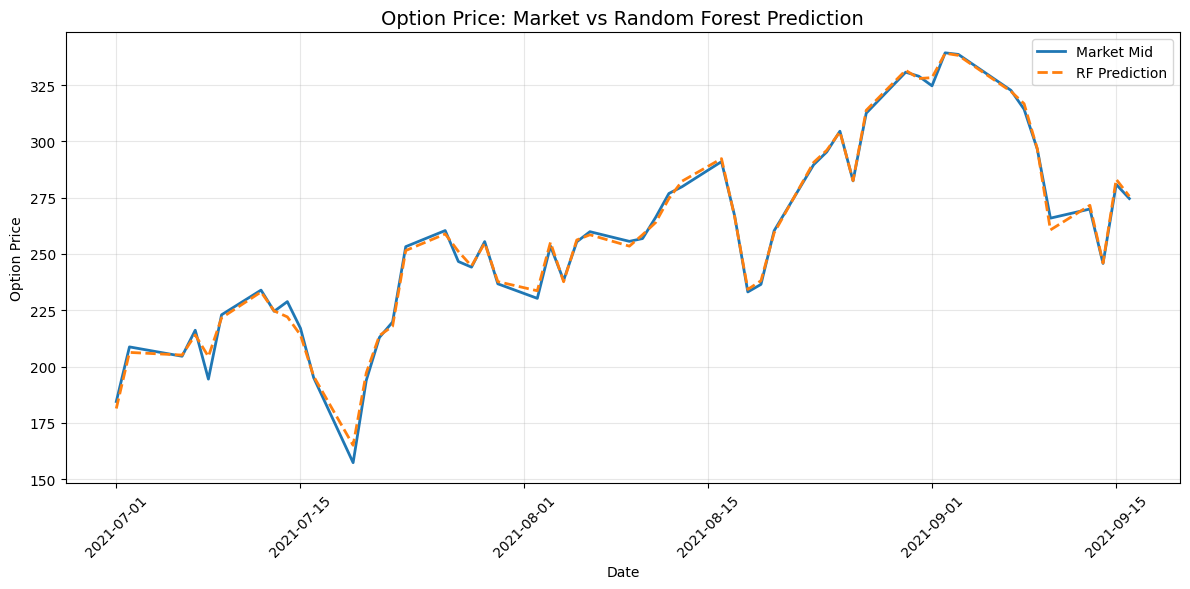

In [29]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print(pred_test)

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(test_df["date"], test_df["mid"], 
        label="Market Mid", linewidth=2)

ax.plot(test_df["date"], pred_test, 
        label="RF Prediction", linewidth=2, linestyle="--")

ax.set_title("Option Price: Market vs Random Forest Prediction", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Option Price")

ax.legend()
ax.grid(True, alpha=0.3)

# Better date formatting
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
